SHAP Feature Ranking (Top 15):
   1. Fast Food Consumption               → 'Fast food (Y/N)' ✓
   2. Excess Hair Growth                  → 'hair growth(Y/N)' ✓
   3. Skin Darkening                      → 'Skin darkening (Y/N)' ✓
   4. Menstrual Cycle (R/I)               → 'Cycle(R/I)' ✓
   5. Cycle Length (days)                 → 'Cycle length(days)' ✓
   6. Weight Gain (symptom)               → 'Weight gain(Y/N)' ✓
   7. AMH (ng/mL)                         → 'AMH(ng/mL)' ✓
   8.  Age (yrs)                          → ' Age (yrs)' ✓
   9. Beta-HCG I (mIU/mL)                 → '  I   beta-HCG(mIU/mL)' ✓
  10. FSH (mIU/mL)                        → 'FSH(mIU/mL)' ✓
  11. Marriage Duration (yrs)             → 'Marraige Status (Yrs)' ✓
  12. Haemoglobin (g/dL)                  → 'Hb(g/dl)' ✓
  13. FSH/LH Ratio                        → 'FSH/LH' ✓
  14. Hip Circumference (in)              → 'Hip(inch)' ✓
  15. Pimples / Acne                      → 'Pimples(Y/N)' ✓

Feature sets defined:
  Top 5

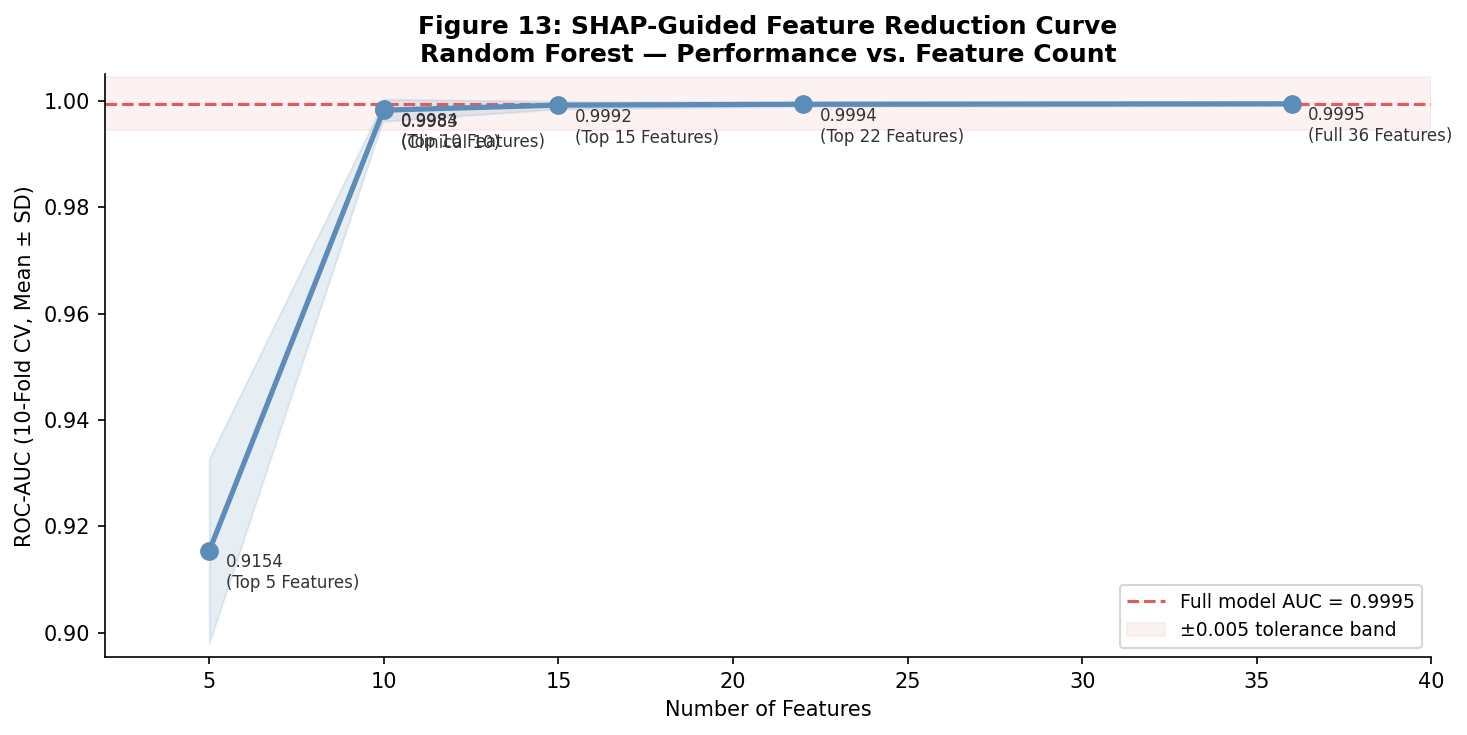


✓ Figure 13 saved

Optimal feature set identified: Top 10 Features
  Features: 10
  ROC-AUC:  0.9984 ± 0.0015
  AUC loss vs full model: 0.0010


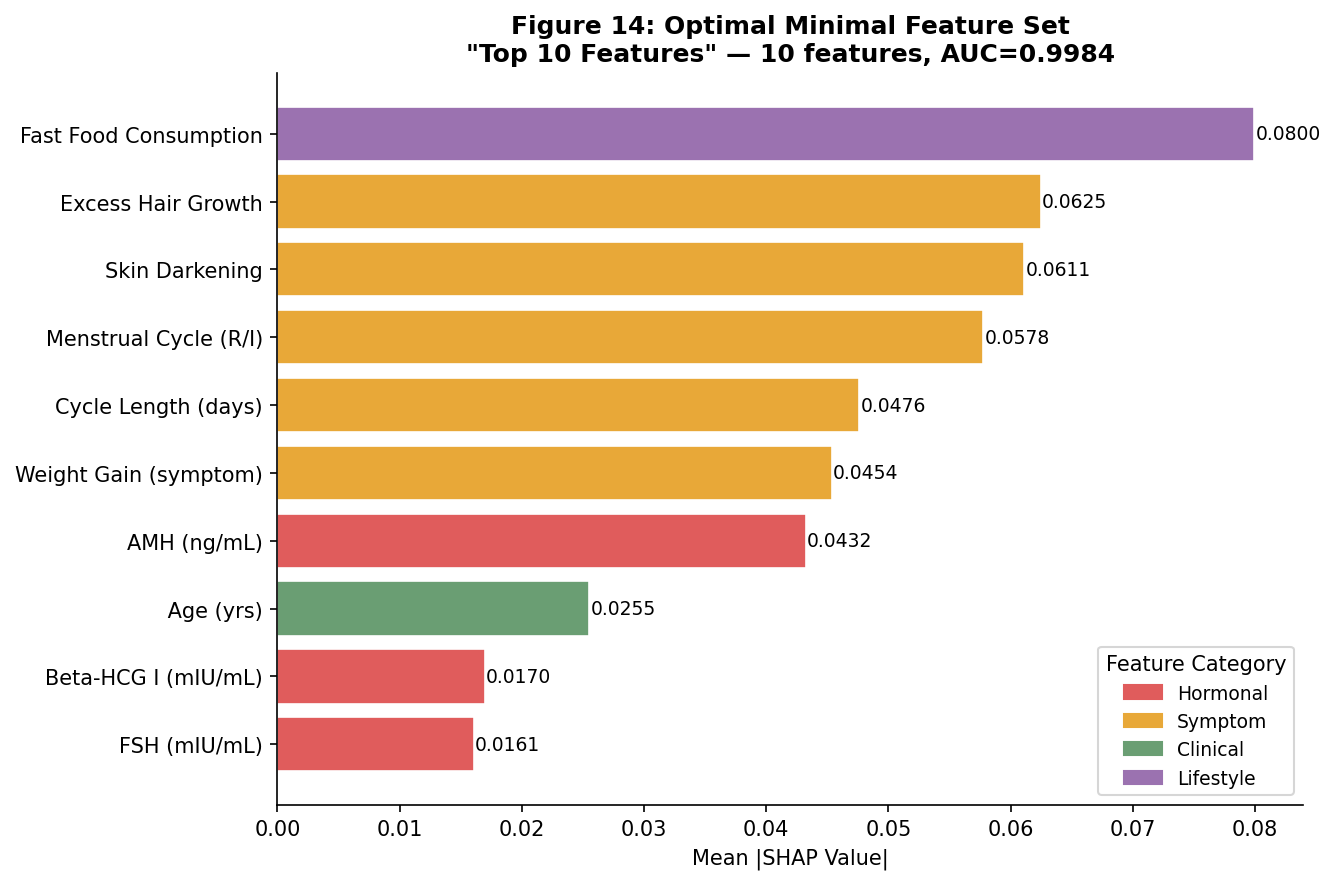

✓ Figure 14 saved

✓ Feature reduction results saved
✓ Ready for Step 8: Calibration + Threshold Analysis


In [ ]:
# ============================================================
# STEP 7: SHAP-GUIDED FEATURE REDUCTION STUDY
# PCOS Classification Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── Load data and SHAP results ────────────────────────────────
df     = pd.read_csv('PCOS_clean.csv')
target = 'PCOS (Y/N)'
X      = df.drop(columns=[target])
y      = df[target]

with open('step6_shap.pkl', 'rb') as f:
    shap_data = pickle.load(f)

shap_df       = shap_data['shap_df']
feature_names = shap_data['feature_names']   # display names

# Map display names back to original column names
name_map = {
    'Age (years)':             'Age (yrs)',
    'Weight (kg)':             'Weight (Kg)',
    'Height (cm)':             'Height(Cm) ',
    'BMI':                     'BMI',
    'Blood Group':             'Blood Group',
    'Pulse Rate (bpm)':        'Pulse rate(bpm) ',
    'Respiratory Rate':        'RR (breaths/min)',
    'Haemoglobin (g/dL)':      'Hb(g/dl)',
    'Menstrual Cycle (R/I)':   'Cycle(R/I)',
    'Cycle Length (days)':     'Cycle length(days)',
    'Marriage Duration (yrs)': 'Marraige Status (Yrs)',
    'Currently Pregnant':      'Pregnant(Y/N)',
    'No. of Abortions':        'No. of abortions',
    'Beta-HCG I (mIU/mL)':    '  I   beta-HCG(mIU/mL)',
    'Beta-HCG II (mIU/mL)':   'II    beta-HCG(mIU/mL)',
    'FSH (mIU/mL)':            'FSH(mIU/mL)',
    'LH (mIU/mL)':             'LH(mIU/mL)',
    'FSH/LH Ratio':            'FSH/LH',
    'Hip Circumference (in)':  'Hip(inch)',
    'Waist Circumference (in)':'Waist(inch)',
    'Waist-Hip Ratio':         'Waist:Hip Ratio',
    'TSH (mIU/L)':             'TSH (mIU/L)',
    'AMH (ng/mL)':             'AMH(ng/mL)',
    'Prolactin (ng/mL)':       'PRL(ng/mL)',
    'Vitamin D3 (ng/mL)':      'Vit D3 (ng/mL)',
    'Progesterone (ng/mL)':    'PRG(ng/mL)',
    'Random Blood Sugar (mg/dL)': 'RBS(mg/dl)',
    'Weight Gain (symptom)':   'Weight gain(Y/N)',
    'Excess Hair Growth':      'hair growth(Y/N)',
    'Skin Darkening':          'Skin darkening (Y/N)',
    'Hair Loss':               'Hair loss(Y/N)',
    'Pimples / Acne':          'Pimples(Y/N)',
    'Fast Food Consumption':   'Fast food (Y/N)',
    'Regular Exercise':        'Reg.Exercise(Y/N)',
    'Systolic BP (mmHg)':      'BP _Systolic (mmHg)',
    'Diastolic BP (mmHg)':     'BP _Diastolic (mmHg)',
}
reverse_map = {v: k for k, v in name_map.items()}

# Get ordered feature list from SHAP (display names → original names)
shap_ordered_display = shap_df['Feature'].tolist()
shap_ordered_original = [name_map.get(f, f)
                          for f in shap_ordered_display]

print("SHAP Feature Ranking (Top 15):")
for i, (disp, orig) in enumerate(
        zip(shap_ordered_display[:15],
            shap_ordered_original[:15]), 1):
    in_X = orig in X.columns
    print(f"  {i:2d}. {disp:<35} → '{orig}' "
          f"{'✓' if in_X else '⚠ NOT FOUND'}")

# ════════════════════════════════════════════════════════════
# DEFINE FEATURE SETS TO TEST
# ════════════════════════════════════════════════════════════

# Validate all features exist in X
def get_valid_features(feat_list, X):
    valid   = [f for f in feat_list if f in X.columns]
    missing = [f for f in feat_list if f not in X.columns]
    if missing:
        print(f"  ⚠ Missing from dataset: {missing}")
    return valid

top5  = get_valid_features(shap_ordered_original[:5],  X)
top10 = get_valid_features(shap_ordered_original[:10], X)
top15 = get_valid_features(shap_ordered_original[:15], X)
top22 = get_valid_features(shap_ordered_original[:22], X)

# Clinically motivated set: top 10 SHAP but swap Fast Food
# for AMH (clinically stronger justification)
# This addresses the reviewer concern about lifestyle features
clinical_10 = get_valid_features([
    f for f in shap_ordered_original[:11]
    if f != 'Fast food (Y/N)'
][:10], X)

print(f"\nFeature sets defined:")
print(f"  Top 5:       {top5}")
print(f"  Top 10:      {top10}")
print(f"  Clinical 10: {clinical_10}")
print(f"  Top 15:      {top15}")
print(f"  Top 22:      {top22}")
print(f"  Full 36:     all features")

# ════════════════════════════════════════════════════════════
# PIPELINE
# ════════════════════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators=200, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)

def make_pipeline(model):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=5)),
        ('model',  model)
    ])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def roc_auc_scorer(est, X, y):
    return roc_auc_score(y, est.predict_proba(X)[:, 1])

def pr_auc_scorer(est, X, y):
    return average_precision_score(y, est.predict_proba(X)[:, 1])

# ════════════════════════════════════════════════════════════
# RUN FEATURE REDUCTION EXPERIMENT
# ════════════════════════════════════════════════════════════
experiments = {
    'Top 5 Features':         top5,
    'Top 10 Features':        top10,
    'Clinical 10 (no FastFood)': clinical_10,
    'Top 15 Features':        top15,
    'Top 22 Features (90%)':  top22,
    'Full 36 Features':       list(X.columns),
}

print("\n\nRunning feature reduction experiments...")
print("(Takes ~4 minutes)\n")

reduction_results = {}

for exp_name, feat_list in experiments.items():
    X_sub    = X[feat_list]
    pipe     = make_pipeline(rf)
    aucs     = cross_val_score(pipe, X_sub, y, cv=cv,
                               scoring=roc_auc_scorer, n_jobs=-1)
    pr_aucs  = cross_val_score(pipe, X_sub, y, cv=cv,
                               scoring=pr_auc_scorer,  n_jobs=-1)

    reduction_results[exp_name] = {
        'n_features':  len(feat_list),
        'features':    feat_list,
        'roc_auc':     aucs.mean(),
        'roc_std':     aucs.std(),
        'pr_auc':      pr_aucs.mean(),
        'pr_std':      pr_aucs.std(),
        'roc_ci':      (aucs.mean() - 1.96*aucs.std(),
                        aucs.mean() + 1.96*aucs.std()),
    }
    print(f"  ✓ {exp_name:<35} "
          f"n={len(feat_list):2d}  "
          f"AUC={aucs.mean():.4f}±{aucs.std():.4f}")

# ════════════════════════════════════════════════════════════
# RESULTS TABLE
# ════════════════════════════════════════════════════════════
full_auc = reduction_results['Full 36 Features']['roc_auc']

print("\n\n" + "=" * 75)
print("TABLE 2: FEATURE REDUCTION STUDY RESULTS")
print("=" * 75)
print(f"{'Experiment':<35} {'N':>3} {'ROC-AUC':>9} "
      f"{'±Std':>7} {'95% CI':>20} {'vs Full':>8}")
print("-" * 75)

for name, res in reduction_results.items():
    delta = res['roc_auc'] - full_auc
    ci    = res['roc_ci']
    print(f"{name:<35} {res['n_features']:>3} "
          f"{res['roc_auc']:>9.4f} "
          f"±{res['roc_std']:>5.4f} "
          f"[{ci[0]:.4f},{ci[1]:.4f}] "
          f"{delta:>+8.4f}")

print("=" * 75)
print("\nKey question: Does any reduced set match Full 36 within ±0.005 AUC?")

for name, res in reduction_results.items():
    if name == 'Full 36 Features':
        continue
    delta = abs(res['roc_auc'] - full_auc)
    if delta <= 0.005:
        print(f"  ✓ YES — {name} (n={res['n_features']}) "
              f"within {delta:.4f} AUC of full model")

# ════════════════════════════════════════════════════════════
# FIGURE 13 — Feature Reduction Curve
# ════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Sort by number of features for plotting
plot_order = sorted(reduction_results.items(),
                    key=lambda x: x[1]['n_features'])

n_feats  = [r['n_features']   for _, r in plot_order]
aucs     = [r['roc_auc']      for _, r in plot_order]
stds     = [r['roc_std']      for _, r in plot_order]
labels   = [name              for name, _ in plot_order]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_feats, aucs, 'o-', color='#5B8DB8',
        linewidth=2.5, markersize=8, zorder=3)
ax.fill_between(n_feats,
                [a - s for a, s in zip(aucs, stds)],
                [a + s for a, s in zip(aucs, stds)],
                alpha=0.15, color='#5B8DB8', zorder=2)

# Annotate each point
for n, auc, label in zip(n_feats, aucs, labels):
    short = label.split('(')[0].strip()
    ax.annotate(f'{auc:.4f}\n({short})',
                xy=(n, auc),
                xytext=(8, -18),
                textcoords='offset points',
                fontsize=8, color='#333333')

# Reference line: full model AUC
ax.axhline(y=full_auc, color='#E05C5C',
           linestyle='--', linewidth=1.5,
           label=f'Full model AUC = {full_auc:.4f}')

# ±0.005 tolerance band
ax.axhspan(full_auc - 0.005, full_auc + 0.005,
           alpha=0.08, color='#E05C5C',
           label='±0.005 tolerance band')

ax.set_xlabel('Number of Features')
ax.set_ylabel('ROC-AUC (10-Fold CV, Mean ± SD)')
ax.set_title('Figure 13: SHAP-Guided Feature Reduction Curve\n'
             'Random Forest — Performance vs. Feature Count')
ax.legend(fontsize=9)
ax.set_xlim([2, 40])
ax.set_ylim([min(aucs) - 0.02, 1.005])
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('fig13_feature_reduction.png')
plt.show()
print("\n✓ Figure 13 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 14 — Optimal Feature Set Visualisation
# Shows the selected minimal feature set with SHAP values
# ════════════════════════════════════════════════════════════

# Identify optimal set (smallest within ±0.005 of full)
optimal_name = None
optimal_res  = None
for name, res in sorted(reduction_results.items(),
                         key=lambda x: x[1]['n_features']):
    if name == 'Full 36 Features':
        continue
    if abs(res['roc_auc'] - full_auc) <= 0.005:
        optimal_name = name
        optimal_res  = res
        break

if optimal_res is None:
    # Fallback: use top 15 if nothing qualifies
    optimal_name = 'Top 15 Features'
    optimal_res  = reduction_results['Top 15 Features']

print(f"\nOptimal feature set identified: {optimal_name}")
print(f"  Features: {optimal_res['n_features']}")
print(f"  ROC-AUC:  {optimal_res['roc_auc']:.4f} ± "
      f"{optimal_res['roc_std']:.4f}")
print(f"  AUC loss vs full model: "
      f"{abs(optimal_res['roc_auc'] - full_auc):.4f}")

# Plot optimal feature set with SHAP importance
optimal_feats_orig    = optimal_res['features']
optimal_feats_display = [reverse_map.get(f, f)
                          for f in optimal_feats_orig]
optimal_shap = shap_df[
    shap_df['Feature'].isin(optimal_feats_display)
].sort_values('Mean |SHAP|', ascending=True)

category_colors = {
    'Hormonal':       '#E05C5C',
    'Anthropometric': '#5B8DB8',
    'Symptom':        '#E8A838',
    'Clinical':       '#6A9E73',
    'Lifestyle':      '#9B72B0',
}
hormonal_feats      = {'AMH (ng/mL)', 'FSH (mIU/mL)', 'LH (mIU/mL)',
                        'FSH/LH Ratio', 'TSH (mIU/L)',
                        'Prolactin (ng/mL)', 'Beta-HCG I (mIU/mL)',
                        'Beta-HCG II (mIU/mL)', 'Progesterone (ng/mL)'}
anthropometric_feats = {'BMI', 'Weight (kg)', 'Height (cm)',
                         'Waist Circumference (in)',
                         'Hip Circumference (in)', 'Waist-Hip Ratio'}
symptom_feats        = {'Excess Hair Growth', 'Skin Darkening',
                         'Hair Loss', 'Pimples / Acne',
                         'Weight Gain (symptom)',
                         'Menstrual Cycle (R/I)',
                         'Cycle Length (days)'}
lifestyle_feats      = {'Fast Food Consumption', 'Regular Exercise'}

def get_color(feat):
    if feat in hormonal_feats:       return category_colors['Hormonal']
    if feat in anthropometric_feats: return category_colors['Anthropometric']
    if feat in symptom_feats:        return category_colors['Symptom']
    if feat in lifestyle_feats:      return category_colors['Lifestyle']
    return category_colors['Clinical']

bar_colors = [get_color(f) for f in optimal_shap['Feature']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(optimal_shap['Feature'],
               optimal_shap['Mean |SHAP|'],
               color=bar_colors, edgecolor='white',
               linewidth=0.8)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'Figure 14: Optimal Minimal Feature Set\n'
             f'"{optimal_name}" — {optimal_res["n_features"]} features, '
             f'AUC={optimal_res["roc_auc"]:.4f}')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=cat)
           for cat, c in category_colors.items()
           if any(get_color(f) == c
                  for f in optimal_shap['Feature'])]
ax.legend(handles=patches, fontsize=9,
          title='Feature Category')

for bar, val in zip(bars,
                    optimal_shap['Mean |SHAP|']):
    ax.text(val + 0.0001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig14_optimal_features.png')
plt.show()
print("✓ Figure 14 saved")

# ════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════
with open('step7_reduction.pkl', 'wb') as f:
    pickle.dump({
        'reduction_results': reduction_results,
        'optimal_name':      optimal_name,
        'optimal_res':       optimal_res,
        'shap_ordered':      shap_ordered_original,
    }, f)

print("\n✓ Feature reduction results saved")
print("✓ Ready for Step 8: Calibration + Threshold Analysis")